In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "test_notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import torch
from omegaconf import OmegaConf

from imrw import imread

from src.build import build_birefnet, build_lora_birefnet
from src.ai.inference.predict import predict
from src.utils.io import load_yaml

In [2]:
cfg = OmegaConf.merge(
    load_yaml("src/config/tune.yaml"),
    load_yaml("src/config/model.yaml"),
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

LORA_CKPT = None
IMAGE_PATH = "local_data/image/backpack_02.jpg"

device: cuda


In [3]:
base_model = build_birefnet(cfg=cfg).to(device)
model = build_lora_birefnet(cfg=cfg, model=base_model, ckpt_path=LORA_CKPT)
model.eval()
print(
    f"total={model.stats['total']:,}  trainable={model.stats['trainable']:,}  "
    f"ratio={model.stats['trainable'] / model.stats['total']:.2%}"
)

[LOAD] weight/BiRefNet-general-epoch_244.pth
total=223,728,282  trainable=3,551,784  ratio=1.59%


In [4]:
image = imread(IMAGE_PATH)
print(f"image: {image.shape}  dtype: {image.dtype}")

pred = predict(model=model, image=image, threshold=None)
print(f"pred: {pred.shape}  dtype: {pred.dtype}")

image: (1280, 1280, 3)  dtype: uint8
pred: (1280, 1280)  dtype: float32


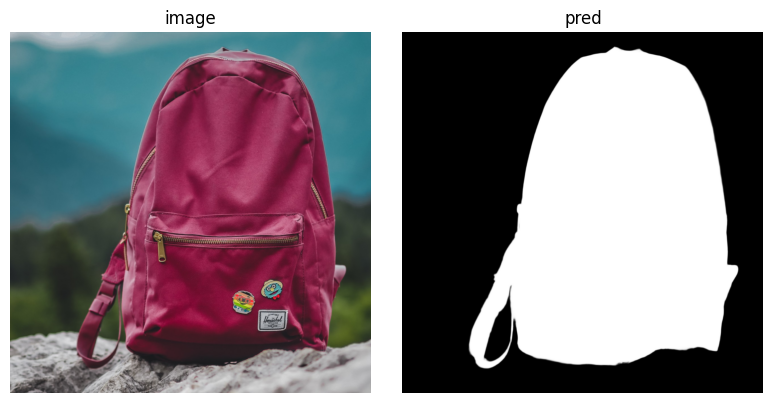

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image)
axes[0].set_title("image")
axes[1].imshow(pred, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("pred")
for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()